Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'clf__C': 10, 'clf__gamma': 'scale', 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Test Accuracy: 0.752029520295203


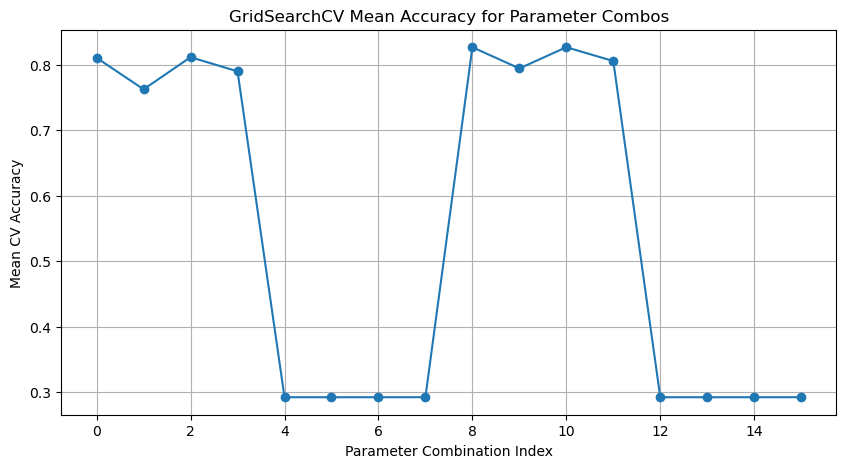

<Figure size 700x700 with 0 Axes>

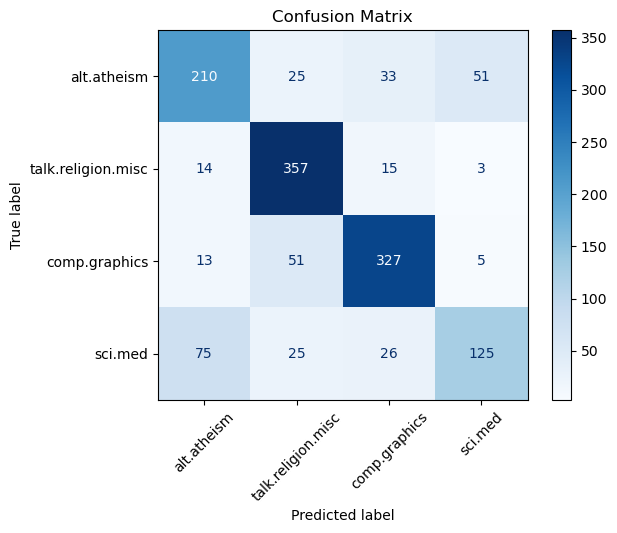

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix

# ---------------------------
# Load dataset
# ---------------------------
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.med']

train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, remove=('headers', 'footers', 'quotes'))
test = fetch_20newsgroups(subset='test', categories=categories, shuffle=True, remove=('headers', 'footers', 'quotes'))

# ---------------------------
# Build Pipeline
# ---------------------------
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', SVC(kernel='rbf'))
])

# ---------------------------
# Hyperparameter Grid
# ---------------------------
param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1, 3],
    'clf__C': [1, 10],
    'clf__gamma': ['scale', 'auto']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)
grid.fit(train.data, train.target)

print("Best parameters:", grid.best_params_)

# ---------------------------
# Evaluation
# ---------------------------
pred = grid.predict(test.data)
acc = accuracy_score(test.target, pred)
print("Test Accuracy:", acc)

# ---------------------------
# Plot CV Results: mean accuracy
# ---------------------------
mean_scores = grid.cv_results_['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(mean_scores, marker='o')
plt.title("GridSearchCV Mean Accuracy for Parameter Combos")
plt.xlabel("Parameter Combination Index")
plt.ylabel("Mean CV Accuracy")
plt.grid(True)
plt.show()

# ---------------------------
# Confusion Matrix
# ---------------------------
cm = confusion_matrix(test.target, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)

plt.figure(figsize=(7, 7))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [16]:
# Test with new document
new_text = [
    "OpenGL on the GPU is faster than on the CPU."
]

prediction = grid.predict(new_text)[0]
predicted_category = train.target_names[prediction]
print("Predicted category:", predicted_category)

Predicted category: comp.graphics
